# Skin Lesion Image Preprocessing

Before training a deep learning model, medical images must be preprocessed to improve consistency and quality.

Preprocessing helps remove unnecessary variations between images while preserving important medical features.

In this notebook, we will learn how to:

- Load skin lesion images
- Resize images
- Normalize pixel values
- Visualize preprocessing results
- Prepare images for CNN training

These preprocessing steps are commonly used in skin cancer classification research.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## Step 1: Load the Metadata

We begin by loading the HAM10000 metadata file.

The metadata allows us to connect each image with its diagnosis label.

In [2]:
dataset_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata = pd.read_csv(
    os.path.join(dataset_path, "HAM10000_metadata.csv")
)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Step 2: Locate Image Files

The HAM10000 images are stored in two folders.

We create a helper function that searches both folders and returns the correct image path.

In [3]:
image_folders = [
    os.path.join(dataset_path, "HAM10000_images_part_1"),
    os.path.join(dataset_path, "HAM10000_images_part_2")
]

def find_image(image_id):

    filename = image_id + ".jpg"

    for folder in image_folders:

        path = os.path.join(folder, filename)

        if os.path.exists(path):
            return path

    return None

## Step 3: Load a Sample Skin Lesion Image

Before preprocessing, let's inspect a real dermoscopic image from the dataset.

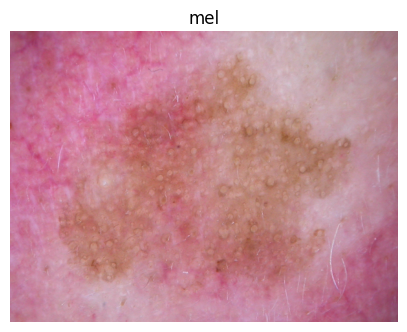

In [4]:
sample = metadata.sample(1, random_state=42).iloc[0]

image_path = find_image(sample["image_id"])

image = Image.open(image_path)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title(sample["dx"])
plt.axis("off")
plt.show()

## Step 4: Resize the Image

Deep learning models require every image to have the same dimensions.

Common input sizes include:

- 128 × 128
- 224 × 224
- 256 × 256

For this notebook, we resize all images to **224 × 224**, which is commonly used with transfer learning models such as MobileNetV2.

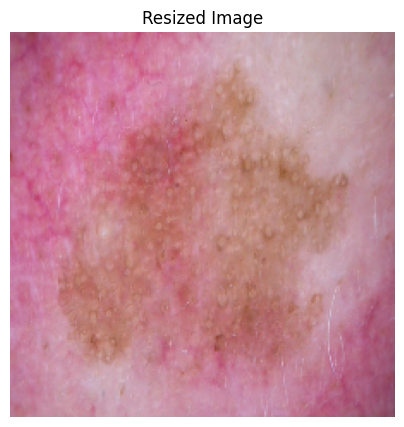

Image Shape: (224, 224, 3)


In [5]:
image_cv = cv2.imread(image_path)

image_rgb = cv2.cvtColor(
    image_cv,
    cv2.COLOR_BGR2RGB
)

resized = cv2.resize(
    image_rgb,
    (224,224)
)

plt.figure(figsize=(5,5))
plt.imshow(resized)
plt.title("Resized Image")
plt.axis("off")
plt.show()

print("Image Shape:", resized.shape)

## Step 5: Normalize Pixel Values

The original pixel values range from **0 to 255**.

Neural networks train more effectively when pixel values are scaled between **0 and 1**.

In [6]:
normalized = resized.astype("float32") / 255.0

print("Minimum Pixel Value:", normalized.min())
print("Maximum Pixel Value:", normalized.max())

Minimum Pixel Value: 0.2
Maximum Pixel Value: 0.9411765


## Step 6: Compare Original and Normalized Images

Normalization changes the numerical values but should not noticeably change the visual appearance of the image.

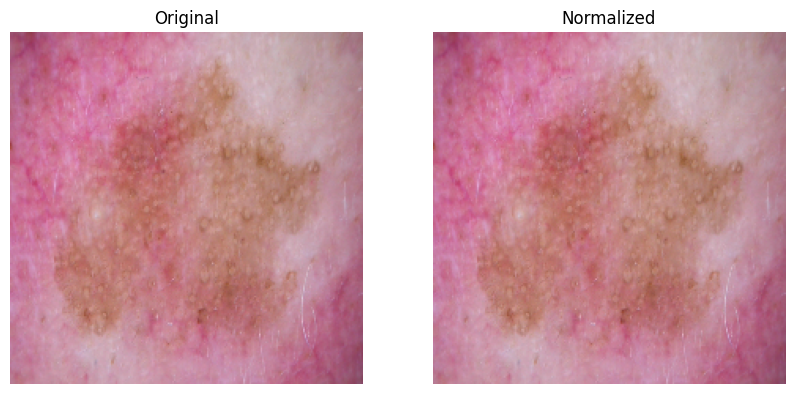

In [7]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(resized)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(normalized)
ax[1].set_title("Normalized")
ax[1].axis("off")

plt.show()

## Step 7: Convert to Grayscale

Although most skin lesion models use RGB images, grayscale conversion is useful for understanding image intensity and reducing computational complexity in certain applications.

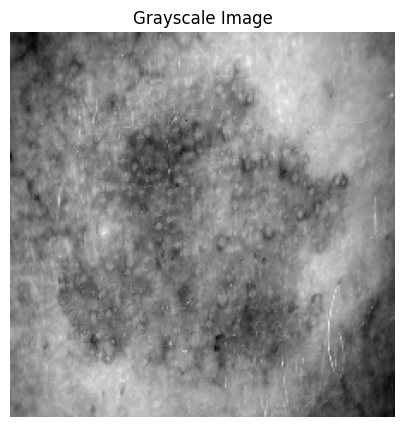

In [8]:
gray = cv2.cvtColor(
    resized,
    cv2.COLOR_RGB2GRAY
)

plt.figure(figsize=(5,5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

## Step 8: Apply Gaussian Blur

Gaussian Blur smooths the image by reducing high-frequency noise.

This technique is sometimes used before edge detection or feature extraction.

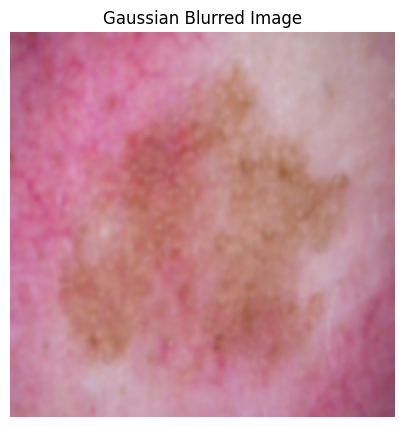

In [9]:
blurred = cv2.GaussianBlur(
    resized,
    (5,5),
    0
)

plt.figure(figsize=(5,5))
plt.imshow(blurred)
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

## Step 9: Compare All Preprocessing Steps

Visualizing each preprocessing stage helps us understand how the image changes throughout the pipeline.

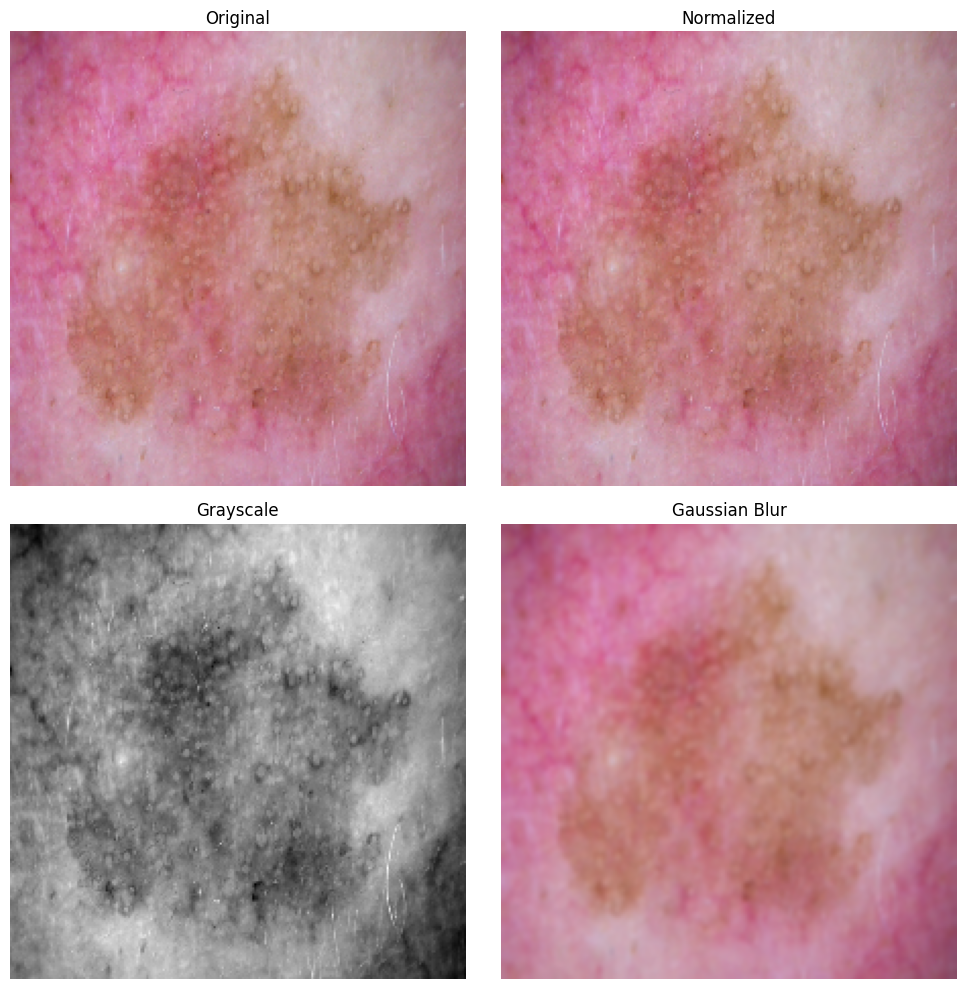

In [10]:
fig, axes = plt.subplots(2,2, figsize=(10,10))

axes[0,0].imshow(resized)
axes[0,0].set_title("Original")
axes[0,0].axis("off")

axes[0,1].imshow(normalized)
axes[0,1].set_title("Normalized")
axes[0,1].axis("off")

axes[1,0].imshow(gray, cmap="gray")
axes[1,0].set_title("Grayscale")
axes[1,0].axis("off")

axes[1,1].imshow(blurred)
axes[1,1].set_title("Gaussian Blur")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()

## Step 10: Why These Steps Matter

These preprocessing techniques are commonly used before training deep learning models.

Typical preprocessing pipeline:

1. Load image
2. Resize
3. Normalize
4. Data augmentation (optional)
5. Feed into CNN or Transfer Learning model

This same workflow will be used in the next notebook when building a skin lesion classifier.

# Summary

In this notebook, I learned how to preprocess dermoscopic skin lesion images using the HAM10000 dataset.

## What I Learned

- How to load real medical images
- Resize images for deep learning
- Normalize pixel values
- Convert images to grayscale
- Apply Gaussian Blur
- Understand a standard preprocessing pipeline

These preprocessing techniques are fundamental for building reliable Medical AI systems and will be used in the next notebook for skin lesion classification.